# Complementaria Semana 10: Cadenas de Markov en Python III

### Enunciado

<div style="background-color: rgba(92, 86, 136, 0.31); padding: 15px; border-left: 5px solid rgb(251, 251, 251); border-radius: 5px; margin-bottom: 15px; box-sizing: border-box; overflow-wrap: break-word; width: 100%;">

En la perforación de pozos (de agua, petróleo, etc) se emplean bombas sumergibles que permiten bombear un líquido. Como la bomba debe sumergirse completamente en el líquido a bombear, está sujeta a condiciones difíciles de operación. Con el objetivo de reducir los costos de mantenimiento se ha desarrollado un modelo de cadenas de Markov que captura el estado de la bomba. 

La bomba puede estar en 5 niveles de corrosión, del 1 al 5, donde 1 indica cero corrosión y 5 indica altísima corrosión. 
El cambio en el nivel de corrosión depende del ambiente en el que se encuentra la máquina, que puede ser de bajo o alto impacto. 
Por lo tanto, se considera que el modelo debe tener dos variables: 
$X(t)$: el nivel de corrosión de la bomba; y $Y(t)$: el nivel de impacto del ambiente. 

En un pozo en particular, se ha estimado que el tiempo que la bomba se encuentra en un ambiente de alto impacto es una variable exponencial con media 4 horas, tras lo cual pasa a un ambiente de bajo impacto, donde pasa un tiempo exponencial con media de 2 horas y media. Después de pasar por el ambiente de bajo impacto, vuelve al ambiente de alto impacto y se repite el ciclo. 

Mientras la bomba está en el ambiente de alto impacto, su nivel de corrosión aumenta un nivel cada 10 horas en promedio; mientras que si la bomba está en un ambiente de bajo impacto, su nivel de corrosión baja un nivel cada 5 horas en promedio. Estos tiempos también siguen una distribución exponencial y son independientes de los tiempos que la bomba pasa en un ambiente de bajo o alto impacto.
</div>

### Preguntas

<div style="background-color: rgba(173, 216, 230, 0.05); padding: 15px; border-left: 5px solid rgb(251, 251, 251); border-radius: 5px; margin-bottom: 15px; box-sizing: border-box; overflow-wrap: break-word; width: 100%;">

1. Modele el sistema como una cadena de Markov en tiempo continuo. Defina claramente las variables de estado, el espacio de estados y construya la matriz generadora de tasas de transición $Q$.

2. Suponga que la bomba inicia operación con el nivel mínimo de corrosión y solo se sabe que, con 50% de probabilidad, el ambiente será de alto impacto. Determine la probabilidad de que, pasada 1 semana de operación, la bomba esté en el nivel máximo de corrosión.

3. Determine la probabilidad de que la bomba se encuentre en cada uno de los niveles de corrosión (del 1 al 5) a largo plazo.

4. Utilizando las probabilidades de estado estable obtenidas en el punto anterior, calcule el nivel de corrosión esperado en el que se encontrará la bomba a largo plazo.

5. Suponga que la empresa ha determinado que operar la bomba tiene un costo por hora $C$ que depende de su nivel de corrosión. Calcule el costo operativo esperado por hora en el largo plazo y estime el costo mensual (asumiendo que un mes tiene 30 días).
$$C(X(t)) = 
\begin{cases} 
0 & \text{si } X(t) = 1 \\ 
25 & \text{si } X(t) = 2 \\ 
50 & \text{si } X(t) = 3 \\ 
100 & \text{si } X(t) = 4 \\ 
250 & \text{si } X(t) = 5 
\end{cases}$$

6. Considere el caso en que la máquina inicia su operación en un ambiente con alto impacto y con un nivel de corrosión de 5. ¿Cuánto tiempo se espera que pase antes de que la máquina llegue por primera vez a un estado con el mínimo nivel de corrosión (1) en un ambiente de bajo impacto?

7. Considere el caso en que la máquina inicia su operación en un ambiente con alto impacto y con un nivel de corrosión de 3 (medio). Si se observa el sistema durante dos semanas:
    - ¿Cuánto tiempo se espera que pase la máquina en cada uno de los estados?
    - Determine el tiempo total esperado que pasará la máquina con un nivel de corrosión mayor al estado inicial.
</div>



### 1. Modelado del sistema como cadena de Markov

<div style="background-color: rgba(173, 216, 230, 0.25); padding: 15px; border-left: 5px solid #ADD8E6; border-radius: 5px; margin-bottom: 15px; box-sizing: border-box; overflow-wrap: break-word; width: 100%;">

*P/ Modele el sistema como una cadena de Markov en tiempo continuo. Defina claramente las variables de estado, el espacio de estados y construya la matriz generadora de tasas de transición $Q$.*
</div>



Variables de estado:

$$X(t): \text{El nivel de corrosión de la bomba.}$$

$$Y(t): \text{El nivel de impacto del ambiente.}$$


Espacio de estados:

$$S_X=\{1,\dots,5\}$$

$$S_Y=\{\text{alto},\text{bajo}\}$$

La cadena se puede describir con la variable compuesta $Z(t)=(X(t),Y(t))$ con espacio de estados $S_Z=S_X\times S_Y$.

Las tasas correspondientes son: 


$$\lambda_{\text{Corr Alto}}=1/10 \ \text{horas}^{-1}$$
$$\lambda_{\text{Corr Bajo}}=1/5 \ \text{horas}^{-1}$$
$$\lambda_{\text{Alto}\to\text{Bajo}}=1/4 \ \text{horas}^{-1}$$
$$\lambda_{\text{Bajo}\to\text{Alto}}=1/2.5 \ \text{horas}^{-1}$$



La matriz generadora es:
$$
Q_{(i,j)\to(i',j')}=
\begin{cases}
\lambda_{\text{Corr Alto}}, & i'=i+1,\ j'=j=\text{Alto},\ i<5,\\
\lambda_{\text{Corr Bajo}}, & i'=i-1,\ j'=j=\text{Bajo},\ i>1,\\
\lambda_{\text{Alto}\to\text{Bajo}}, & i'=i,\ j=\text{Alto},\ j'=\text{Bajo},\\
\lambda_{\text{Bajo}\to\text{Alto}}, & i'=i,\ j=\text{Bajo},\ j'=\text{Alto},\\
0, & \text{d.l.c.}
\end{cases}
$$

Con esto, podemos implementar la matriz generadora en Python


In [ ]:
#Importar las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from jmarkov.ctmc import ctmc

#Tasas a utilizar
tasa_corrosion_alto = 1/10
tasa_corrosion_bajo = 1/5
tasa_ambiente_alto_bajo = 1/4
tasa_ambiente_bajo_alto = 1/2.5

# Generar espacio de estados
estados_corrosion = [i for i in range(1,6)]
estados_ambiente = ['Alto', 'Bajo']

estados = []
for i in estados_corrosion:
    for j in estados_ambiente:
        estados.append((i, j))
estados

[(1, 'Alto'),
 (1, 'Bajo'),
 (2, 'Alto'),
 (2, 'Bajo'),
 (3, 'Alto'),
 (3, 'Bajo'),
 (4, 'Alto'),
 (4, 'Bajo'),
 (5, 'Alto'),
 (5, 'Bajo')]

In [2]:
# Crear las etiquetas de texto para los estados
etiquetas = [str(estado) for estado in estados]

# Inicializar la matriz Q llena de ceros con las etiquetas de texto
matrizQ = pd.DataFrame(0.0, index=etiquetas, columns=etiquetas)
matrizQ 

,"(1, 'Alto')","(1, 'Bajo')","(2, 'Alto')","(2, 'Bajo')","(3, 'Alto')","(3, 'Bajo')","(4, 'Alto')","(4, 'Bajo')","(5, 'Alto')","(5, 'Bajo')"
"(1, 'Alto')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(1, 'Bajo')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(2, 'Alto')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(2, 'Bajo')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(3, 'Alto')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(3, 'Bajo')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(4, 'Alto')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(4, 'Bajo')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(5, 'Alto')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(5, 'Bajo')",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Se define la matriz inicialmente en ceros y se recorre por fila y por columna para ir ingresando las tasas según las condiciones de la formulación.
$$
Q_{(i,j)\to(i',j')}=
\begin{cases}
\lambda_{\text{Corr Alto}}, & i'=i+1,\ j'=j=\text{Alto},\ i<5,\\
\lambda_{\text{Corr Bajo}}, & i'=i-1,\ j'=j=\text{Bajo},\ i>1,\\
\lambda_{\text{Alto}\to\text{Bajo}}, & i'=i,\ j=\text{Alto},\ j'=\text{Bajo},\\
\lambda_{\text{Bajo}\to\text{Alto}}, & i'=i,\ j=\text{Bajo},\ j'=\text{Alto},\\
0, & \text{d.l.c.}
\end{cases}
$$

In [3]:
# Llenar la matriz Q
for (i, j) in estados:
    estado_actual = str((i, j)) # Convertimos la tupla actual a texto

    # Aumento del nivel de corrosión (hasta un máximo de 5)
    if i < 5 and j == 'Alto':
        estado_futuro = str((i + 1, j))
        matrizQ.loc[estado_actual, estado_futuro] = tasa_corrosion_alto   
        
    # Disminución del nivel de corrosión (hasta un mínimo de 1)
    if i > 1 and j == 'Bajo':
        estado_futuro = str((i - 1, j))
        matrizQ.loc[estado_actual, estado_futuro] = tasa_corrosion_bajo

        
    # Cambio de ambiente: de Alto impacto a Bajo impacto
    if j == 'Alto':
        estado_futuro = str((i, 'Bajo'))
        matrizQ.loc[estado_actual, estado_futuro] = tasa_ambiente_alto_bajo
        
    # Cambio de ambiente: de Bajo impacto a Alto impacto
    if j == 'Bajo':
        estado_futuro = str((i, 'Alto'))
        matrizQ.loc[estado_actual, estado_futuro] = tasa_ambiente_bajo_alto

matrizQ

,"(1, 'Alto')","(1, 'Bajo')","(2, 'Alto')","(2, 'Bajo')","(3, 'Alto')","(3, 'Bajo')","(4, 'Alto')","(4, 'Bajo')","(5, 'Alto')","(5, 'Bajo')"
"(1, 'Alto')",0.0,0.25,0.1,0.00,0.0,0.00,0.0,0.00,0.0,0.00
"(1, 'Bajo')",0.4,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00
"(2, 'Alto')",0.0,0.00,0.0,0.25,0.1,0.00,0.0,0.00,0.0,0.00
"(2, 'Bajo')",0.0,0.20,0.4,0.00,0.0,0.00,0.0,0.00,0.0,0.00
"(3, 'Alto')",0.0,0.00,0.0,0.00,0.0,0.25,0.1,0.00,0.0,0.00
"(3, 'Bajo')",0.0,0.00,0.0,0.20,0.4,0.00,0.0,0.00,0.0,0.00
"(4, 'Alto')",0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.25,0.1,0.00
"(4, 'Bajo')",0.0,0.00,0.0,0.00,0.0,0.20,0.4,0.00,0.0,0.00
"(5, 'Alto')",0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.25
"(5, 'Bajo')",0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.20,0.4,0.00


Se debe ajustar la diagonal de manera que las filas sumen cero:

$$
q_{ii} = -\sum_{j\neq i} q_{ij}
$$

In [4]:
# Ajustar la diagonal
filas_suma = matrizQ.sum(axis=1)
for estado in estados:
    estado_actual = str(estado)
    matrizQ.loc[estado_actual, estado_actual] = -filas_suma[estado_actual]

# Verificación
print("Suma por filas (debe ser ≈ 0):", np.allclose(matrizQ.sum(axis=1), 0))
print(f"Tamaño de Q: {matrizQ.shape}")

matrizQ

Suma por filas (debe ser ≈ 0): True
Tamaño de Q: (10, 10)


,"(1, 'Alto')","(1, 'Bajo')","(2, 'Alto')","(2, 'Bajo')","(3, 'Alto')","(3, 'Bajo')","(4, 'Alto')","(4, 'Bajo')","(5, 'Alto')","(5, 'Bajo')"
"(1, 'Alto')",-0.35,0.25,0.10,0.00,0.00,0.00,0.00,0.00,0.00,0.00
"(1, 'Bajo')",0.40,-0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
"(2, 'Alto')",0.00,0.00,-0.35,0.25,0.10,0.00,0.00,0.00,0.00,0.00
"(2, 'Bajo')",0.00,0.20,0.40,-0.60,0.00,0.00,0.00,0.00,0.00,0.00
"(3, 'Alto')",0.00,0.00,0.00,0.00,-0.35,0.25,0.10,0.00,0.00,0.00
"(3, 'Bajo')",0.00,0.00,0.00,0.20,0.40,-0.60,0.00,0.00,0.00,0.00
"(4, 'Alto')",0.00,0.00,0.00,0.00,0.00,0.00,-0.35,0.25,0.10,0.00
"(4, 'Bajo')",0.00,0.00,0.00,0.00,0.00,0.20,0.40,-0.60,0.00,0.00
"(5, 'Alto')",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.25,0.25
"(5, 'Bajo')",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.20,0.40,-0.60


In [5]:
# Crear la cadena de Markov en tiempo continuo usando jmarkov
cadena = ctmc(matrizQ.to_numpy())

print(f"Número de estados: {cadena.n_states}")
print(f"¿Es irreducible?: {cadena.is_irreducible()}")
print(f"¿Es ergódica?: {cadena.is_ergodic()}")

Número de estados: 10
¿Es irreducible?: True
¿Es ergódica?: True


In [6]:
# Crear un diccionario para asignarle un índice númerico a cada estado
mapa_indices = {estado: idx for idx, estado in enumerate(estados)}

# Función rápida para obtener el índice de cualquier estado
def index(i, j):
    return mapa_indices[(i, j)]

mapa_indices

{(1, 'Alto'): 0,
 (1, 'Bajo'): 1,
 (2, 'Alto'): 2,
 (2, 'Bajo'): 3,
 (3, 'Alto'): 4,
 (3, 'Bajo'): 5,
 (4, 'Alto'): 6,
 (4, 'Bajo'): 7,
 (5, 'Alto'): 8,
 (5, 'Bajo'): 9}

### 2. Análisis Transitorio: Evolución desde baja corrosión


<div style="background-color: rgba(173, 216, 230, 0.25); padding: 15px; border-left: 5px solid #ADD8E6; border-radius: 5px; margin-bottom: 15px; box-sizing: border-box; overflow-wrap: break-word; width: 100%;">
  <i>P/ Suponga que la bomba inicia operación con el nivel mínimo de corrosión y solo se sabe que, con 50% de probabilidad, el ambiente será de alto impacto. Determine la probabilidad de que, pasada 1 semana de operación, la bomba esté en el nivel máximo de corrosión.</i>
</div>


Esto es una probabilidad en el transitorio. Como no conocemos con exactitud desde qué estado se inicia, se define el vector de probabilidades iniciales de la siguiente manera:


$$
\pi_{(i,j)}(0)=\begin{cases}
0.5, & i=1,\ j\in\{\text{alto},\text{bajo}\},\\
0, & \text{d.l.c.}
\end{cases}
$$

La probabilidad de que **tras 1 semana** ($24\times 7$ horas) la bomba esté en el **nivel 5** es:

$$
\sum_{j\in S_Y} \big[\ \pi(0)\, e^{Q\,(24\times 7)}\ \big]_{(5,j)}
$$


Para calcular la distribución de probabilidad en Python, se utilizará el método `transient_probabilities` de la librería `jmarkov` que recibe como parámetro el vector inicial `alpha` y el tiempo transcurrido $24\times 7$

In [7]:
#Definir la distribución inicial
alpha = np.zeros(len(estados))
alpha[index(1, 'Alto')]=0.5
alpha[index(1, 'Bajo')]=0.5

#Analizar las probabilidades de estado transitorio

probs_transitorio = cadena.transient_probabilities(t=24*7, alpha=alpha)
estado_interes1 = index(5, 'Alto')
estado_interes2 = index(5, 'Bajo')

#Calcular la probabilidad de interés
prob_interes = probs_transitorio[estado_interes1] + probs_transitorio[estado_interes2]
prob_interes

np.float64(0.16419361020232148)

### 3. Probabilidades en Estado Estable por Nivel de Corrosión

<div style="background-color: rgba(173, 216, 230, 0.25); padding: 15px; border-left: 5px solid #ADD8E6; border-radius: 5px; margin-bottom: 15px; box-sizing: border-box; overflow-wrap: break-word; width: 100%;">
  <i>P/ Determine la probabilidad de que la bomba se encuentre en cada uno de los niveles de corrosión (del 1 al 5) a largo plazo.</i>
</div>


Para calcular esta probabilidad primero debemos obtener la distribución en estado estable del sistema $\pi$. Luego, encontramos la distribución marginal para el nivel de corrosión $X(t)$, sumando las probabilidades de los ambientes para cada nivel $i$:
$$
P(X = i) = \pi_{(i, \text{Alto})} + \pi_{(i, \text{Bajo})}
$$

In [9]:
# Calcular la distribución en estado estable
pi_estable = cadena.steady_state()

# Inicializar diccionario para las probabilidades marginales de corrosión (niveles 1 al 5)
prob_marg_corrosion = {i: 0.0 for i in range(1, 6)}

# Iteramos sobre los estados para sumar la probabilidad marginal
for idx, (i, j) in enumerate(estados):
    prob_marg_corrosion[i] += pi_estable[idx]

# Mostrar resultados
print("Probabilidades en Estado Estable por Nivel de Corrosión:")
for nivel, probabilidad in prob_marg_corrosion.items():
    print(f"Nivel {nivel}: {probabilidad:.4f}")

Probabilidades en Estado Estable por Nivel de Corrosión:
Nivel 1: 0.2901
Nivel 2: 0.2100
Nivel 3: 0.1800
Nivel 4: 0.1543
Nivel 5: 0.1656


### 4. Valor Esperado del Nivel de Corrosión

<div style="background-color: rgba(173, 216, 230, 0.25); padding: 15px; border-left: 5px solid #ADD8E6; border-radius: 5px; margin-bottom: 15px; box-sizing: border-box; overflow-wrap: break-word; width: 100%;">
  <i>P/ Utilizando las probabilidades de estado estable obtenidas en el punto anterior, calcule el nivel de corrosión esperado en el que se encontrará la bomba a largo plazo.</i>
</div>

El valor esperado nos indica el nivel de corrosión promedio en el que se encontrará la bomba a largo plazo. Se calcula multiplicando cada nivel de corrosión por su probabilidad de ocurrir en estado estable y sumando los resultados:
$$
\mathbb{E}[X] = \sum_{i=1}^{5} i \cdot P(X = i)
$$

In [10]:
# Inicializamos el valor esperado
valor_esperado_corrosion = 0.0

# Calculamos E[X] iterando sobre todos los estados en estado estable
for idx, (i, j) in enumerate(estados):
    # Multiplicamos el nivel por su probabilidad correspondiente
    valor_esperado_corrosion += i * pi_estable[idx]

print(f"El nivel de corrosión esperado a largo plazo es: {valor_esperado_corrosion:.4f}")

El nivel de corrosión esperado a largo plazo es: 2.6954


### 5. Costo Esperado del Sistema

<div style="background-color: rgba(173, 216, 230, 0.25); padding: 15px; border-left: 5px solid #ADD8E6; border-radius: 5px; margin-bottom: 15px; box-sizing: border-box; overflow-wrap: break-word; width: 100%;">

*P/ Suponga que la empresa ha determinado que operar la bomba tiene un costo por hora $C$ que depende de su nivel de corrosión. Calcule el costo operativo esperado por hora en el largo plazo y estime el costo mensual (asumiendo que un mes tiene 30 días).*

$$C(X(t)) = 
\begin{cases} 
0 & \text{si } X(t) = 1 \\ 
25 & \text{si } X(t) = 2 \\ 
50 & \text{si } X(t) = 3 \\ 
100 & \text{si } X(t) = 4 \\ 
250 & \text{si } X(t) = 5 
\end{cases}$$

</div>

El costo esperado por hora en estado estable $\mathbb{E}[C]$ se puede calcular utilizando la distribucion en estado estable obtenida en el punto (3) como:
$$\mathbb{E}[C] = \sum_{i=1}^{5} C(i) \cdot P(X = i)$$

In [11]:
# Definimos un diccionario con el costo por hora para cada nivel de corrosión
costos_por_nivel = {
    1: 0.0, 
    2: 25.0,  
    3: 50.0,  
    4: 100.0, 
    5: 250.0 
}

# Inicializamos el costo esperado
costo_esperado_hora = 0.0

# Calculamos E[C] sumando (costo del estado * probabilidad del estado)
for idx, (i, j) in enumerate(estados):
    costo_del_estado = costos_por_nivel[i]
    costo_esperado_hora += costo_del_estado * pi_estable[idx]

print(f"El costo operativo esperado por hora es: ${costo_esperado_hora:.2f}")

# Si queremos el costo esperado mensual:
costo_esperado_mensual = costo_esperado_hora * 24 * 30
print(f"El costo operativo esperado mensual es: ${costo_esperado_mensual:.2f}")

El costo operativo esperado por hora es: $71.09
El costo operativo esperado mensual es: $51182.66


### 6. Tiempos de Primera Pasada


<div style="background-color: rgba(173, 216, 230, 0.25); padding: 15px; border-left: 5px solid #ADD8E6; border-radius: 5px; margin-bottom: 15px; box-sizing: border-box; overflow-wrap: break-word; width: 100%;">
  <i>P/ Considere el caso en que la máquina inicia su operación en un ambiente con alto impacto y con un nivel de corrosión de 5. ¿Cuánto tiempo se espera que pase antes de que la máquina llegue por primera vez a un estado con el mínimo nivel de corrosión (1) en un ambiente de bajo impacto?</i>
</div>

Esto se trata de un tiempo de primera pasada. La máquina inicia en $Z(0)=(5,\text{alto})$. El tiempo promedio de primera pasada al estado objetivo $(1,\text{bajo})$ se denota por:
$$
m_{(5,\text{alto})\to(1,\text{bajo})}.
$$

Sea $\bar{Q}$ la matriz $Q$ sin la fila/columna del estado objetivo. Entonces,


$$
m = \bar Q^{-1}\,\mathbf{1},\quad m_{(5,\text{alto})\to(1,\text{bajo})} = [m]_{(5,\text{alto})}.
$$

(Equivalente) resolver el sistema lineal:

$$
r(i,j)\,m_{(i,j)\to(1,\text{bajo})}
= 1 + \sum_{(k,\ell)\neq(1,\text{bajo})} q_{(i,j),(k,\ell)}\, m_{(k,\ell)\to(1,\text{bajo})}.
$$

Para calcular en Python el tiempo mencionado se utilizará el método `first_passage_time` de la librería `jmarkov` que recibe como parámetro el estado futuro. Además se debe indicar el estado inicial.

In [12]:
# Calcular el tiempo de primera pasada 
#estados de interés
estado_inicial = index(5, 'Alto')
estado_futuro = index(1, 'Bajo')

# Calcular los tiempos de primera pasada a (1, 'Bajo')
tiempos_pp = cadena.first_passage_time(estado_futuro)

# Obtener el tiempo de primera pasada desde (5, 'Alto') a (1, 'Bajo')
tiempo_1_5 = tiempos_pp[estado_inicial][0]
print(f"El tiempo promedio para pasar por primera vez de (5, 'Alto') a (1, 'Bajo') es: {tiempo_1_5:.2f} horas")

El tiempo promedio para pasar por primera vez de (5, 'Alto') a (1, 'Bajo') es: 92.48 horas


### 7. Tiempos de Ocupación por Nivel de Corrosión

<div style="background-color: rgba(173, 216, 230, 0.25); padding: 15px; border-left: 5px solid #ADD8E6; border-radius: 5px; margin-bottom: 15px; box-sizing: border-box; overflow-wrap: break-word; width: 100%;">

*P/ Considere el caso en que la máquina inicia su operación en un ambiente con alto impacto y con un nivel de corrosión de 3 (medio). Si se observa el sistema durante dos semanas:*
* *¿Cuánto tiempo se espera que pase la máquina en cada uno de los estados?*
* *Determine el tiempo total esperado que pasará la máquina con un nivel de corrosión mayor al estado inicial.*

</div>

Esta pregunta se refiere a un tiempo de ocupación para $2\times 7\times 24$ horas, que calculamos como:

$$
\mathbf{M}^{t} = \int_{0}^{2\times7\times24} e^{Q u}\,du
$$

El tiempo esperado que la máquina pasa con un nivel de corrosión mayor al estado inicial se puede calcular realizando la sumatoria:

$$
\sum_{i=4}^{5}\ \sum_{j\in S_Y}
\left[ \mathbf{M}^{t} \right]_{(3,\text{alto}),(i,j)}
$$

Para calcular en Python el tiempo mencionado se utilizará el método `occupation_time` de la librería `jmarkov` que recibe como parámetro el tiempo de interés $2\times 7\times 24$

In [ ]:
# Definir parámetros de tiempo y estado inicial
tiempo_evaluacion = 2 * 7 * 24 
idx_inicial = index(3, 'Alto')

# Calcular la matriz de ocupación con jmarkov
matriz_ocup = cadena.occupation_time(tiempo_evaluacion)

# Inicializar estructuras de almacenamiento
tiempo_interes = 0.0
# Para el heatmap creamos una matriz de 5 filas y 2 columnas
matriz_heatmap = np.zeros((5, 2))
mapa_ambiente = {'Alto': 0, 'Bajo': 1} # Diccionario auxiliar para las columnas

# Unificar cálculos en un solo bucle FOR
for idx_destino, (i, j) in enumerate(estados):
    
    # Extraer el tiempo que pasa en el estado destino
    tiempo_en_estado = matriz_ocup[idx_inicial, idx_destino]

    # Llenar la matriz para el heatmap
    columna = mapa_ambiente[j]
    matriz_heatmap[i - 1, columna] = tiempo_en_estado
    
    # Calcular tiempo de interés: niveles estrictamente mayores al inicial
    if i >= 4:
        tiempo_interes += tiempo_en_estado

# Imprimir el tiempo solicitado
print(f"Tiempo esperado con corrosión mayor al inicial (Niveles 4 y 5): {tiempo_interes:.4f} horas")

Tiempo esperado con corrosión mayor al inicial (Niveles 4 y 5): 109.0914 horas


Suma de tiempos: 336.00 horas


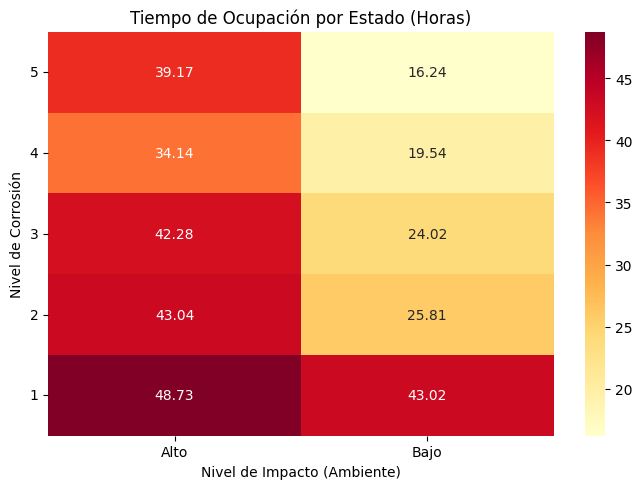

In [15]:
# Graficar el Heatmap con todos los tiempos
print(f"Suma de tiempos: {sum(matriz_heatmap.flatten()):.2f} horas")

plt.figure(figsize=(7, 5))
ax = sns.heatmap(matriz_heatmap, annot=True, fmt=".2f", cmap="YlOrRd",
                 xticklabels=['Alto', 'Bajo'], 
                 yticklabels=[1, 2, 3, 4, 5])
ax.invert_yaxis()
plt.title('Tiempo de Ocupación por Estado (Horas)')
plt.xlabel('Nivel de Impacto (Ambiente)')
plt.ylabel('Nivel de Corrosión')
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

Universidad de los Andes | Vigilada Mineducación. Reconocimiento como Universidad: Decreto 1297 del 30 de mayo de 1964. Reconocimiento personería jurídica: Resolución 28 del 23 de febrero de 1949 Minjusticia. Departamento de Ingeniería Industrial Carrera 1 Este No. 19 A 40 Bogotá, Colombia Tel. (57.1) 3324320 | (57.1) 3394949 Ext. 2880 /2881 http://industrial.uniandes.edu.co